In [1]:
from __future__ import annotations
import math
from pathlib import Path
import torch
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torch import nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import random
from collections import defaultdict

## Infra

### 1.数据集处理

#### 1.1 Cars

In [2]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp"}


class CarsDataset(Dataset):
    def __init__(self, samples, image_size=(224, 224)):
        self.samples = samples
        self.image_size = image_size

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        image_path, label = self.samples[idx]

        with Image.open(image_path) as img:
            img = img.convert("RGB")
            img = img.resize(self.image_size, Image.BILINEAR)

            img_array = np.array(img, dtype=np.float32) / 255.0
            img_tensor = torch.from_numpy(img_array).permute(2, 0, 1)

        return img_tensor, label


def get_cars_dataloader(
    data_dir="../data/Cars",
    image_size=(224, 224),
    batch_size=32,
    test_ratio=0.2,
    num_workers=0,
    shuffle_train=True,
    split_mode="ordered",  # "ordered" 或 "random"
    seed=42,
):
    """
    split_mode:
    - "ordered": 按文档规则，每个类别按文件名排序后取最后 test_ratio 作为测试集
    - "random" : 每个类别内部随机打乱后，再按 test_ratio 划分测试集
    """
    if not 0.2 <= test_ratio <= 0.3:
        raise ValueError("test_ratio 必须在 0.2 到 0.3 之间")

    if split_mode not in {"ordered", "random"}:
        raise ValueError("split_mode 只能是 'ordered' 或 'random'")

    data_dir = Path(data_dir)
    if not data_dir.exists():
        raise FileNotFoundError(f"数据目录不存在: {data_dir}")

    class_dirs = sorted([p for p in data_dir.iterdir() if p.is_dir()])
    if not class_dirs:
        raise ValueError(f"没有找到类别文件夹: {data_dir}")

    rng = random.Random(seed)

    train_samples = []
    test_samples = []

    for label, class_dir in enumerate(class_dirs):
        image_paths = [
            p
            for p in class_dir.iterdir()
            if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
        ]

        if not image_paths:
            continue

        image_paths = sorted(image_paths)

        if split_mode == "random":
            rng.shuffle(image_paths)

        test_count = max(1, math.floor(len(image_paths) * test_ratio))
        split_idx = len(image_paths) - test_count

        train_samples.extend((p, label) for p in image_paths[:split_idx])
        test_samples.extend((p, label) for p in image_paths[split_idx:])

    if split_mode == "random":
        rng.shuffle(train_samples)
        rng.shuffle(test_samples)

    train_dataset = CarsDataset(train_samples, image_size=image_size)
    test_dataset = CarsDataset(test_samples, image_size=image_size)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=shuffle_train,
        num_workers=num_workers,
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
    )

    return train_loader, test_loader

In [3]:
train_loader, test_loader = get_cars_dataloader(
    image_size=(224, 224),
    batch_size=32,
    test_ratio=0.2,
)

images, labels = next(iter(train_loader))

print("images.shape =", images.shape)
print("labels.shape =", labels.shape)
print("images.dtype =", images.dtype)
print("labels.dtype =", labels.dtype)

images.shape = torch.Size([32, 3, 224, 224])
labels.shape = torch.Size([32])
images.dtype = torch.float32
labels.dtype = torch.int64


#### 1.2 Dehaze

In [4]:
class DehazeDataset(Dataset):
    def __init__(self, samples, image_size=(256, 256)):
        self.samples = samples
        self.image_size = image_size

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        haze_path, clear_path = self.samples[idx]

        with Image.open(haze_path) as haze_img:
            haze_img = haze_img.convert("RGB")
            haze_img = haze_img.resize(self.image_size, Image.BILINEAR)
            haze_array = np.array(haze_img, dtype=np.float32) / 255.0
            haze_tensor = torch.from_numpy(haze_array).permute(2, 0, 1)

        with Image.open(clear_path) as clear_img:
            clear_img = clear_img.convert("RGB")
            clear_img = clear_img.resize(self.image_size, Image.BILINEAR)
            clear_array = np.array(clear_img, dtype=np.float32) / 255.0
            clear_tensor = torch.from_numpy(clear_array).permute(2, 0, 1)

        return haze_tensor, clear_tensor


def get_dehaze_dataloader(
    data_dir="../data/Dehaze",
    image_size=(256, 256),
    batch_size=16,
    test_ratio=0.2,
    num_workers=0,
    shuffle_train=True,
):
    """
    按文档规则划分：
    - haze 和 clear 按同名文件配对
    - 按文件名排序
    - 后 20% 作为测试集
    - 返回 train_loader, test_loader
    """
    if abs(test_ratio - 0.2) > 1e-8:
        raise ValueError("去雾数据集按文档要求应使用后 20% 作为测试集")

    data_dir = Path(data_dir)
    haze_dir = data_dir / "haze"
    clear_dir = data_dir / "clear"

    if not haze_dir.exists() or not clear_dir.exists():
        raise FileNotFoundError(f"未找到 haze/clear 目录: {data_dir}")

    haze_files = sorted(
        [
            p for p in haze_dir.iterdir()
            if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
        ]
    )

    if not haze_files:
        raise ValueError(f"{haze_dir} 下没有找到图像文件")

    samples = []
    for haze_path in haze_files:
        clear_path = clear_dir / haze_path.name
        if not clear_path.exists():
            raise FileNotFoundError(f"缺少配对清晰图像: {clear_path}")
        samples.append((haze_path, clear_path))

    test_count = max(1, math.floor(len(samples) * test_ratio))
    split_idx = len(samples) - test_count

    train_samples = samples[:split_idx]
    test_samples = samples[split_idx:]

    train_dataset = DehazeDataset(train_samples, image_size=image_size)
    test_dataset = DehazeDataset(test_samples, image_size=image_size)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=shuffle_train,
        num_workers=num_workers,
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
    )

    return train_loader, test_loader

In [5]:
train_loader, test_loader = get_dehaze_dataloader(
    image_size=(256, 256),
    batch_size=16,
)

haze_images, clear_images = next(iter(train_loader))
print(haze_images.shape)   # torch.Size([16, 3, 256, 256])
print(clear_images.shape)  # torch.Size([16, 3, 256, 256])

torch.Size([16, 3, 256, 256])
torch.Size([16, 3, 256, 256])


### 2.训练评估代码

#### 2.1 评估

In [6]:
def prepare_target(y_hat, y, task_type):
    """
    把标签整理成损失函数需要的形状和类型。
    """
    if task_type == "regression":
        return y.to(y_hat.dtype).reshape_as(y_hat)

    if task_type == "multiclass":
        return y.long().reshape(-1)

    raise ValueError(f"未知任务类型: {task_type}")


def batch_correct(y_hat, y, task_type):
    """
    返回一个 batch 中分类正确的样本数。
    回归任务不计算 accuracy，返回 0。
    """
    if task_type == "regression":
        return 0

    if task_type == "multiclass":
        pred = y_hat.argmax(dim=1)
        label = y.long().reshape(-1)
        return (pred == label).sum().item()

    raise ValueError(f"未知任务类型: {task_type}")


def evaluate(model, data_loader, loss_fn, task_type, device, data_range=1.0):
    model.eval()

    loss_sum = 0.0
    sample_count = 0

    correct = 0

    mae_sum = 0.0
    mse_sum = 0.0
    ssim_sum = 0.0
    pixel_count = 0

    with torch.no_grad():
        for X, y in data_loader:
            X = X.to(device)
            y = y.to(device)

            y_hat = model(X)
            target = prepare_target(y_hat, y, task_type)
            loss = loss_fn(y_hat, target)

            batch_size = X.shape[0]
            loss_sum += loss.item() * batch_size
            sample_count += batch_size

            if task_type == "multiclass":
                correct += batch_correct(y_hat, y, task_type)

            elif task_type == "regression":
                pred = y_hat.clamp(0.0, data_range)
                target = target.clamp(0.0, data_range)

                mae_sum += F.l1_loss(pred, target, reduction="sum").item()
                mse_sum += F.mse_loss(pred, target, reduction="sum").item()
                ssim_sum += (
                    ssim(
                        pred,
                        target,
                        data_range=data_range,
                        size_average=True,
                    ).item()
                    * batch_size
                )

                pixel_count += target.numel()

    avg_loss = loss_sum / sample_count

    if task_type == "multiclass":
        metrics = {
            "acc": correct / sample_count,
        }
        return avg_loss, metrics

    if task_type == "regression":
        mae = mae_sum / pixel_count
        mse = mse_sum / pixel_count
        rmse = math.sqrt(mse)
        psnr = float("inf") if mse == 0 else 10.0 * math.log10((data_range**2) / mse)
        mean_ssim = ssim_sum / sample_count

        metrics = {
            "mae": mae,
            "rmse": rmse,
            "psnr": psnr,
            "ssim": mean_ssim,
        }
        return avg_loss, metrics

    raise ValueError(f"未知任务类型: {task_type}")


#### 2.2 训练

In [7]:
def train_model(
    model,
    train_loader,
    test_loader,
    loss_fn,
    optimizer,
    num_epochs,
    task_type,
    device,
):
    history = {
        "train_loss": [],
        "test_loss": [],
    }

    if task_type == "multiclass":
        history.update(
            {
                "train_acc": [],
                "test_acc": [],
            }
        )
    else:
        history.update(
            {
                "test_mae": [],
                "test_rmse": [],
                "test_psnr": [],
                "test_ssim": [],
            }
        )

    model.to(device)

    for epoch in range(num_epochs):
        model.train()

        train_loss_sum = 0.0
        train_correct = 0
        sample_count = 0

        for X, y in train_loader:
            X = X.to(device)
            y = y.to(device)

            optimizer.zero_grad()

            y_hat = model(X)
            target = prepare_target(y_hat, y, task_type)
            loss = loss_fn(y_hat, target)

            loss.backward()
            optimizer.step()

            batch_size = X.shape[0]
            train_loss_sum += loss.item() * batch_size
            sample_count += batch_size

            if task_type == "multiclass":
                train_correct += batch_correct(y_hat, y, task_type)

        train_loss = train_loss_sum / sample_count
        test_loss, test_metrics = evaluate(
            model=model,
            data_loader=test_loader,
            loss_fn=loss_fn,
            task_type=task_type,
            device=device,
        )

        history["train_loss"].append(train_loss)
        history["test_loss"].append(test_loss)

        if task_type == "multiclass":
            train_acc = train_correct / sample_count
            test_acc = test_metrics["acc"]

            history["train_acc"].append(train_acc)
            history["test_acc"].append(test_acc)

            print(
                f"epoch {epoch + 1:03d} | "
                f"train loss {train_loss:.4f} | test loss {test_loss:.4f} | "
                f"train acc {train_acc:.4f} | test acc {test_acc:.4f}"
            )
        else:
            history["test_mae"].append(test_metrics["mae"])
            history["test_rmse"].append(test_metrics["rmse"])
            history["test_psnr"].append(test_metrics["psnr"])
            history["test_ssim"].append(test_metrics["ssim"])

            print(
                f"epoch {epoch + 1:03d} | "
                f"train loss {train_loss:.4f} | test loss {test_loss:.4f} | "
                f"MAE {test_metrics['mae']:.6f} | "
                f"RMSE {test_metrics['rmse']:.6f} | "
                f"PSNR {test_metrics['psnr']:.4f} | "
                f"SSIM {test_metrics['ssim']:.4f}"
            )

    return history

### 4.设备

In [8]:
def try_gpu(i: int = 0) -> torch.device:
    """
    尝试获取第i号GPU设备，无GPU返回CPU
    Args:
        i: GPU卡号，默认0号卡
    Returns:
        torch.device
    """
    if torch.cuda.is_available():
        return torch.device(f"cuda:{i}")
    return torch.device("cpu")

### 3.图像回归损失函数

In [9]:
from pytorch_msssim import ssim


class L1SSIMLoss(nn.Module):
    def __init__(self, alpha=0.8, data_range=1.0):
        super().__init__()
        self.alpha = alpha
        self.l1 = nn.L1Loss()
        self.data_range = data_range

    def forward(self, pred, target):
        pred = pred.clamp(0.0, 1.0)
        target = target.clamp(0.0, 1.0)

        l1_loss = self.l1(pred, target)
        ssim_loss = 1.0 - ssim(
            pred,
            target,
            data_range=self.data_range,
            size_average=True,
        )
        return self.alpha * l1_loss + (1.0 - self.alpha) * ssim_loss

### 4.图像绘制

#### 4.1 loss曲线

In [10]:
def plot_loss_curve(history, fig_name, output_dir="./output"):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    fig, ax = plt.subplots(figsize=(7, 4))

    ax.plot(history["train_loss"], label="train loss")
    ax.plot(history["test_loss"], label="test loss")

    ax.set_xlabel("epoch")
    ax.set_ylabel("loss")
    ax.set_title(f"loss: {fig_name}")
    ax.legend()
    ax.grid(True, alpha=0.3)

    save_path = output_dir / f"loss_{fig_name}.png"
    fig.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()
    plt.close(fig)

    return save_path

#### 4.2 acc曲线

In [11]:
def plot_acc_curve(history, fig_name, output_dir="./output"):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    fig, ax = plt.subplots(figsize=(7, 4))

    ax.plot(history["train_acc"], label="train acc")
    ax.plot(history["test_acc"], label="test acc")

    ax.set_xlabel("epoch")
    ax.set_ylabel("accuracy")
    ax.set_title(f"accuracy: {fig_name}")
    ax.legend()
    ax.grid(True, alpha=0.3)

    save_path = output_dir / f"acc_{fig_name}.png"
    fig.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()
    plt.close(fig)

    return save_path

#### 4.3 对比实验loss曲线

In [12]:
def plot_loss_curves(
    history_list,
    task_list,
    fig_name,
    loss_type="test",
    output_dir="./output",
):
    assert loss_type in ["train", "test"], "loss_type 只能是 'train' 或 'test'"
    assert len(history_list) == len(task_list), "history_list 和 task_list 长度必须一致"

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    fig, ax = plt.subplots(figsize=(7, 4))

    key = f"{loss_type}_loss"

    for history, task in zip(history_list, task_list):
        ax.plot(history[key], label=task)

    ax.set_xlabel("epoch")
    ax.set_ylabel("loss")
    ax.set_title(f"{loss_type} loss: {fig_name}")
    ax.legend()
    ax.grid(True, alpha=0.3)

    save_path = output_dir / f"{loss_type}_loss_{fig_name}.png"
    fig.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()
    plt.close(fig)

    return save_path

### 5.样例分析

#### 5.1 Cars分类

In [13]:
class_names = ["bus", "car", "truck"]


def predict_random_one_per_class(model, test_loader, class_names, device=None, seed=42):
    if device is None:
        device = next(model.parameters()).device

    model.eval()
    dataset = test_loader.dataset
    rng = random.Random(seed)

    class_to_indices = defaultdict(list)
    for idx, (_, label) in enumerate(dataset.samples):
        class_to_indices[label].append(idx)

    chosen_indices = [rng.choice(class_to_indices[i]) for i in range(len(class_names))]

    fig, axes = plt.subplots(
        1, len(chosen_indices), figsize=(4 * len(chosen_indices), 4)
    )
    if len(chosen_indices) == 1:
        axes = [axes]

    with torch.no_grad():
        for ax, idx in zip(axes, chosen_indices):
            image_tensor, label = dataset[idx]

            x = image_tensor.unsqueeze(0).to(device)
            logits = model(x)
            pred = logits.argmax(dim=1).item()

            image = image_tensor.permute(1, 2, 0).cpu().numpy()

            ax.imshow(image)
            ax.set_title(f"true: {class_names[label]}\npred: {class_names[pred]}")
            ax.axis("off")

            image_path, _ = dataset.samples[idx]
            print(f"idx={idx}")
            print(f"path={image_path}")
            print(f"true={class_names[label]}, pred={class_names[pred]}")
            print("-" * 50)

    plt.tight_layout()
    plt.show()

#### 5.2 去雾

In [14]:
def show_dehaze_random_samples(model, test_loader, num_samples=3, device=None, seed=42):
    if device is None:
        device = next(model.parameters()).device

    model.eval()
    dataset = test_loader.dataset
    rng = random.Random(seed)

    num_samples = min(num_samples, len(dataset))
    indices = rng.sample(range(len(dataset)), num_samples)

    fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4 * num_samples))
    if num_samples == 1:
        axes = [axes]

    with torch.no_grad():
        for row_axes, idx in zip(axes, indices):
            hazy_tensor, clear_tensor = dataset[idx]

            x = hazy_tensor.unsqueeze(0).to(device)
            pred_tensor = model(x).squeeze(0).cpu().clamp(0.0, 1.0)

            hazy_img = hazy_tensor.permute(1, 2, 0).cpu().numpy()
            pred_img = pred_tensor.permute(1, 2, 0).numpy()
            clear_img = clear_tensor.permute(1, 2, 0).cpu().numpy()

            row_axes[0].imshow(hazy_img)
            row_axes[0].set_title("hazy input")
            row_axes[0].axis("off")

            row_axes[1].imshow(pred_img)
            row_axes[1].set_title("pred output")
            row_axes[1].axis("off")

            row_axes[2].imshow(clear_img)
            row_axes[2].set_title("clear target")
            row_axes[2].axis("off")

            print(f"idx={idx}")
            if hasattr(dataset, "samples"):
                sample = dataset.samples[idx]
                if isinstance(sample, (list, tuple)) and len(sample) >= 2:
                    print(f"hazy_path={sample[0]}")
                    print(f"clear_path={sample[1]}")
            print("-" * 50)

    plt.tight_layout()
    plt.show()

## 二维卷积实验

### 1.手写二维卷积

#### 1.1 单通道卷积

In [53]:
def corr2d(X: torch.Tensor, K: torch.Tensor):
    batch_size, H, W = X.shape
    k_h, k_w = K.shape
    Y = X.new_zeros((batch_size, H - k_h + 1, W - k_w + 1))

    for i in range(Y.shape[1]):
        for j in range(Y.shape[2]):
            patch = X[:, i : i + k_h, j : j + k_w]  # [B, k_h, k_w]
            Y[:, i, j] = (patch * K.unsqueeze(0)).sum(dim=(1, 2))

    return Y

In [16]:
X = torch.tensor([[[0, 1, 2], [3, 4, 5], [6, 7, 8]]])
K = torch.tensor([[0, 1], [2, 3]])
corr2d(X, K)

tensor([[[19., 25.],
         [37., 43.]]])

#### 1.2 多通道->单通道

In [54]:
def corr2d_multi_in(X, K):
    res = corr2d(X[:, 0, :, :], K[0, :, :])
    for i in range(1, X.shape[1]):
        res += corr2d(X[:, i, :, :], K[i, :, :])
    return res

In [55]:
X = torch.tensor([[[[0, 1, 2], [3, 4, 5], [6, 7, 8]], [[1, 2, 3], [4, 5, 6], [7, 8, 9]]]])
K = torch.tensor([[[0, 1], [2, 3]], [[1, 2], [3, 4]]])
corr2d_multi_in(X, K)

tensor([[[ 56,  72],
         [104, 120]]])

#### 1.3 多通道->多通道

In [56]:
def corr2d_multi_in_out(X, K):
    return torch.stack([corr2d_multi_in(X, k) for k in K], dim=1)

#### 1.4 封装

In [57]:
class MyConv2D(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size):
        super().__init__()
        # 初始化卷积层的2个参数：卷积核、偏差
        if isinstance(kernel_size, int):
            kernel_size = (kernel_size, kernel_size)
        self.weight = nn.Parameter(
            torch.randn((out_channels, in_channels) + kernel_size)
        )
        self.bias = nn.Parameter(torch.randn((out_channels, 1, 1)))

    def forward(self, x):
        # x：输入图片，维度(batch_size,C_in,H,W)
        return corr2d_multi_in_out(x, self.weight) + self.bias


class MyConvModule(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        # 定义三层卷积（这里只写了第一层自定义Conv，后续可补齐）
        self.conv = nn.Sequential(
            MyConv2D(in_channels=3, out_channels=32, kernel_size=3),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
        )
        # 输出层，将通道数变为分类数量
        self.fc = nn.Linear(32, num_classes)

    def forward(self, X):
        # 图片先经过卷积，输出维度(batch_size,C_out,H,W)
        out = self.conv(X)
        # 使用平均池化层将图片的大小变为1x1
        # out = F.avg_pool2d(out, 30) # 这里要求原始图像大小为32,32，过3,3卷积核后变30,30
        out = F.adaptive_avg_pool2d(out, output_size=(1, 1))
        # 将张量从shape batch x 32 x 1 x 1 变为 batch x 32
        out = torch.flatten(out, 1)
        # 输入到全连接层将输出的维度变为类别数
        out = self.fc(out)
        return out

In [ ]:
myconv = MyConvModule(num_classes=10)
test_input = torch.randn(4, 3, 32, 32)
pred = myconv(test_input)
print("输出shape:", pred.shape)  # torch.Size([4, 10])

输出shape: torch.Size([4, 10])


#### 1.5 分类实验

In [ ]:
image_size = (32, 32)
batch_size = 512
num_classes = 3
lr = 1e-3
epochs = 100

train_loader, test_loader = get_cars_dataloader(image_size=image_size, batch_size=batch_size)

myconv = MyConvModule(num_classes=num_classes)
optimizer = torch.optim.SGD(
    myconv.parameters(),
    lr=lr,
)

myconv_multiclass_history = train_model(
    myconv,
    train_loader,
    test_loader,
    loss_fn=nn.CrossEntropyLoss(),
    optimizer=optimizer,
    num_epochs=epochs,
    task_type="multiclass",
    device=try_gpu(),
)

plot_loss_curve(myconv_multiclass_history, "myconv_multiclass")
# 太慢了

### 2.torch.nn实现二维卷积

In [27]:
class ConvModule(nn.Module):
    def __init__(self, num_classes):
        super(ConvModule, self).__init__()
        # 定义三层卷积堆叠
        self.conv = nn.Sequential(
            nn.Conv2d(
                in_channels=3, out_channels=32, kernel_size=3, stride=1, padding=0
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(
                in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=0
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(
                in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=0
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
        )
        # 输出全连接层
        self.fc = nn.Linear(128, num_classes)

    def forward(self, X):
        # 经过三层卷积提取特征
        out = self.conv(X)
        # 平均池化压缩为1×1特征图
        out = F.adaptive_avg_pool2d(out, output_size=(1, 1))
        # 剔除多余1×1空间维度
        out = torch.flatten(out, 1)
        # 分类输出
        out = self.fc(out)
        return out

epoch 001 | train loss 1.0296 | test loss 1.1005 | train acc 0.6007 | test acc 0.2667
epoch 002 | train loss 1.0000 | test loss 1.1095 | train acc 0.6421 | test acc 0.2667
epoch 003 | train loss 0.9746 | test loss 1.0995 | train acc 0.6615 | test acc 0.2704
epoch 004 | train loss 0.9514 | test loss 1.0594 | train acc 0.6651 | test acc 0.3704
epoch 005 | train loss 0.9310 | test loss 0.9993 | train acc 0.6799 | test acc 0.5778
epoch 006 | train loss 0.9130 | test loss 0.9429 | train acc 0.6817 | test acc 0.7111
epoch 007 | train loss 0.8976 | test loss 0.9004 | train acc 0.6983 | test acc 0.7185
epoch 008 | train loss 0.8825 | test loss 0.8748 | train acc 0.6983 | test acc 0.7074
epoch 009 | train loss 0.8694 | test loss 0.8561 | train acc 0.6918 | test acc 0.7111
epoch 010 | train loss 0.8556 | test loss 0.8420 | train acc 0.6992 | test acc 0.7148
epoch 011 | train loss 0.8448 | test loss 0.8297 | train acc 0.6983 | test acc 0.7148
epoch 012 | train loss 0.8344 | test loss 0.8217 | tra

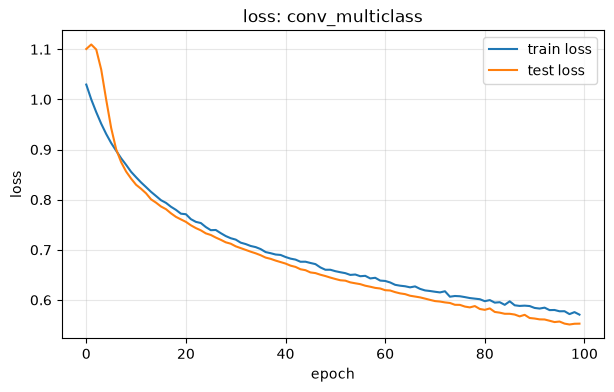

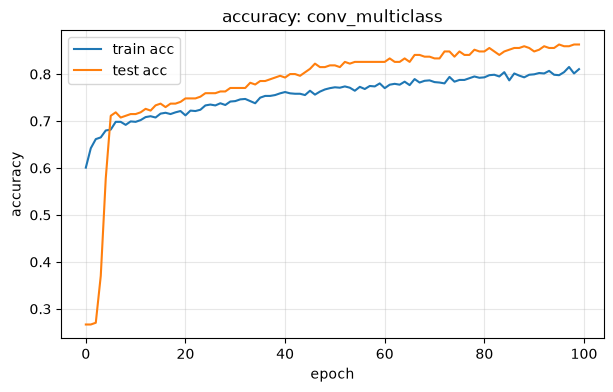

PosixPath('output/acc_conv_multiclass.png')

In [ ]:
name = "conv_multiclass"

image_size = (128, 128)
batch_size = 128
num_classes = 3
lr = 1e-3
epochs = 100

train_loader, test_loader = get_cars_dataloader(
    image_size=image_size, batch_size=batch_size, split_mode="random"
)

conv = ConvModule(num_classes=num_classes)
optimizer = torch.optim.SGD(conv.parameters(), lr=lr, weight_decay=1e-4)

conv_multiclass_history = train_model(
    conv,
    train_loader,
    test_loader,
    loss_fn=nn.CrossEntropyLoss(),
    optimizer=optimizer,
    num_epochs=epochs,
    task_type="multiclass",
    device=try_gpu(),
)


plot_loss_curve(conv_multiclass_history, name)
plot_acc_curve(conv_multiclass_history, name)

idx=221
path=../data/Cars/bus/bus115.jpg
true=bus, pred=car
--------------------------------------------------
idx=30
path=../data/Cars/car/car096.jpg
true=car, pred=car
--------------------------------------------------
idx=34
path=../data/Cars/truck/truck148.jpg
true=truck, pred=truck
--------------------------------------------------


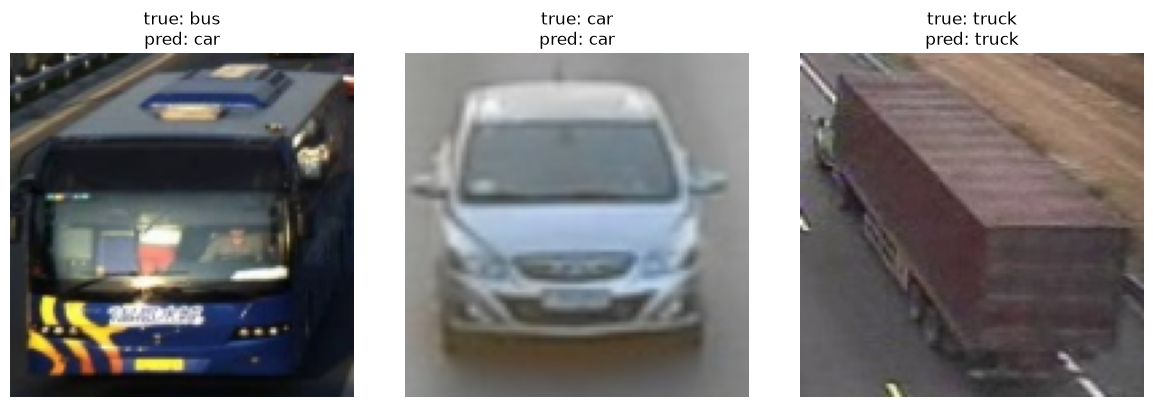

In [43]:
predict_random_one_per_class(
    model=conv,
    test_loader=test_loader,
    class_names=class_names,
    device=try_gpu(),
    seed=677,
)

### 3.batch_size对比实验

epoch 001 | train loss 1.0125 | test loss 0.9328 | train acc 0.5253 | test acc 0.7370
epoch 002 | train loss 0.8629 | test loss 0.8009 | train acc 0.7443 | test acc 0.7704
epoch 003 | train loss 0.7882 | test loss 0.7419 | train acc 0.7424 | test acc 0.7667
epoch 004 | train loss 0.7510 | test loss 0.7096 | train acc 0.7314 | test acc 0.7815
epoch 005 | train loss 0.7199 | test loss 0.6768 | train acc 0.7470 | test acc 0.7963
epoch 006 | train loss 0.6953 | test loss 0.6604 | train acc 0.7562 | test acc 0.8037
epoch 007 | train loss 0.6771 | test loss 0.6374 | train acc 0.7672 | test acc 0.8037
epoch 008 | train loss 0.6624 | test loss 0.6280 | train acc 0.7626 | test acc 0.8148
epoch 009 | train loss 0.6541 | test loss 0.6125 | train acc 0.7663 | test acc 0.8111
epoch 010 | train loss 0.6536 | test loss 0.6018 | train acc 0.7764 | test acc 0.8185
epoch 011 | train loss 0.6318 | test loss 0.5901 | train acc 0.7792 | test acc 0.8333
epoch 012 | train loss 0.6222 | test loss 0.5853 | tra

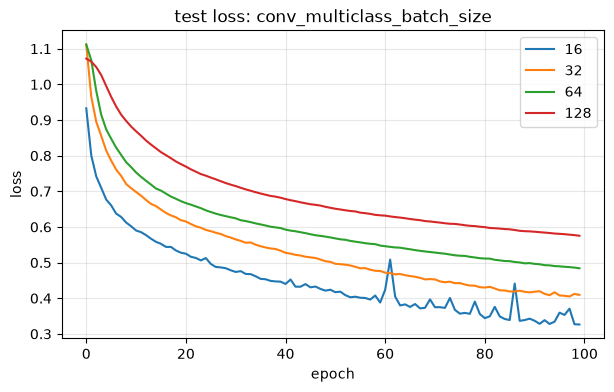

PosixPath('output/test_loss_conv_multiclass_batch_size.png')

In [16]:
batch_sizes = [16, 32, 64, 128]
name = "conv_multiclass_batch_size"

his = []
tasks = [str(x) for x in batch_sizes]
for batch_size in batch_sizes:
    # image_size = (128, 128)
    image_size = (32, 32)
    # batch_size = 128
    num_classes = 3
    lr = 1e-3
    epochs = 100

    train_loader, test_loader = get_cars_dataloader(
        image_size=image_size, batch_size=batch_size, split_mode="random"
    )

    conv = ConvModule(num_classes=num_classes)
    optimizer = torch.optim.SGD(conv.parameters(), lr=lr, weight_decay=1e-4)

    conv_multiclass_history = train_model(
        conv,
        train_loader,
        test_loader,
        loss_fn=nn.CrossEntropyLoss(),
        optimizer=optimizer,
        num_epochs=epochs,
        task_type="multiclass",
        device=try_gpu(),
    )
    his.append(conv_multiclass_history)

plot_loss_curves(history_list=his, task_list=tasks, fig_name=name)


epoch 001 | train loss 1.0354 | test loss 1.0765 | train acc 0.5998 | test acc 0.2667
epoch 002 | train loss 1.0255 | test loss 1.0291 | train acc 0.6302 | test acc 0.6481
epoch 003 | train loss 1.0177 | test loss 1.0144 | train acc 0.6421 | test acc 0.6963
epoch 004 | train loss 1.0087 | test loss 1.0049 | train acc 0.6725 | test acc 0.7074
epoch 005 | train loss 1.0010 | test loss 0.9970 | train acc 0.6881 | test acc 0.7185
epoch 006 | train loss 0.9927 | test loss 0.9886 | train acc 0.6900 | test acc 0.7222
epoch 007 | train loss 0.9850 | test loss 0.9800 | train acc 0.7019 | test acc 0.7296
epoch 008 | train loss 0.9785 | test loss 0.9736 | train acc 0.7102 | test acc 0.7296
epoch 009 | train loss 0.9710 | test loss 0.9662 | train acc 0.7102 | test acc 0.7333
epoch 010 | train loss 0.9625 | test loss 0.9593 | train acc 0.7148 | test acc 0.7370
epoch 011 | train loss 0.9566 | test loss 0.9534 | train acc 0.7222 | test acc 0.7333
epoch 012 | train loss 0.9501 | test loss 0.9464 | tra

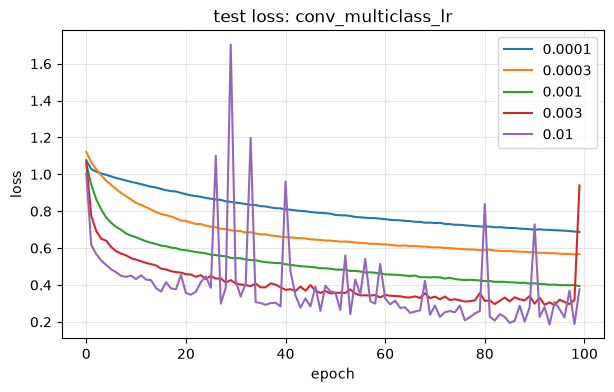

PosixPath('output/test_loss_conv_multiclass_lr.png')

In [17]:
lr_list = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2]
name = "conv_multiclass_lr"

his = []
tasks = [str(x) for x in lr_list]
for lr in lr_list:
    # image_size = (128, 128)
    image_size = (32, 32)
    # batch_size = 128
    num_classes = 3
    epochs = 100
    batch_size = 32

    train_loader, test_loader = get_cars_dataloader(
        image_size=image_size, batch_size=batch_size, split_mode="random"
    )

    conv = ConvModule(num_classes=num_classes)
    optimizer = torch.optim.SGD(conv.parameters(), lr=lr, weight_decay=1e-4)

    conv_multiclass_history = train_model(
        conv,
        train_loader,
        test_loader,
        loss_fn=nn.CrossEntropyLoss(),
        optimizer=optimizer,
        num_epochs=epochs,
        task_type="multiclass",
        device=try_gpu(),
    )
    his.append(conv_multiclass_history)

plot_loss_curves(history_list=his, task_list=tasks, fig_name=name)

### 4.AlexNet

In [14]:
class AlexNet(nn.Module):
    def __init__(self, num_classes=3, dropout=0.5):
        super().__init__()

        self.features = nn.Sequential(
            # 227x227x3 -> 55x55x96
            nn.Conv2d(
                in_channels=3, out_channels=96, kernel_size=11, stride=4, padding=0
            ),
            nn.ReLU(inplace=True),
            # 55x55x96 -> 27x27x96
            nn.MaxPool2d(kernel_size=3, stride=2),
            # 27x27x96 -> 27x27x256
            nn.Conv2d(
                in_channels=96, out_channels=256, kernel_size=5, stride=1, padding=2
            ),
            nn.ReLU(inplace=True),
            # 27x27x256 -> 13x13x256
            nn.MaxPool2d(kernel_size=3, stride=2),
            # 13x13x256 -> 13x13x384
            nn.Conv2d(
                in_channels=256, out_channels=384, kernel_size=3, stride=1, padding=1
            ),
            nn.ReLU(inplace=True),
            # 13x13x384 -> 13x13x384
            nn.Conv2d(
                in_channels=384, out_channels=384, kernel_size=3, stride=1, padding=1
            ),
            nn.ReLU(inplace=True),
            # 标准 AlexNet 还有这一层
            # 13x13x384 -> 13x13x256
            nn.Conv2d(
                in_channels=384, out_channels=256, kernel_size=3, stride=1, padding=1
            ),
            nn.ReLU(inplace=True),
            # 13x13x256 -> 6x6x256
            nn.MaxPool2d(kernel_size=3, stride=2),
        )

        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

epoch 001 | train loss 1.0846 | test loss 1.0676 | train acc 0.5658 | test acc 0.5741
epoch 002 | train loss 1.0518 | test loss 1.0368 | train acc 0.5741 | test acc 0.5741
epoch 003 | train loss 1.0255 | test loss 1.0142 | train acc 0.5741 | test acc 0.5741
epoch 004 | train loss 1.0065 | test loss 0.9974 | train acc 0.5741 | test acc 0.5741
epoch 005 | train loss 0.9919 | test loss 0.9864 | train acc 0.5741 | test acc 0.5741
epoch 006 | train loss 0.9821 | test loss 0.9767 | train acc 0.5741 | test acc 0.5741
epoch 007 | train loss 0.9736 | test loss 0.9710 | train acc 0.5741 | test acc 0.5741
epoch 008 | train loss 0.9675 | test loss 0.9664 | train acc 0.5741 | test acc 0.5741
epoch 009 | train loss 0.9641 | test loss 0.9641 | train acc 0.5741 | test acc 0.5741
epoch 010 | train loss 0.9624 | test loss 0.9630 | train acc 0.5741 | test acc 0.5741
epoch 011 | train loss 0.9618 | test loss 0.9619 | train acc 0.5741 | test acc 0.5741
epoch 012 | train loss 0.9604 | test loss 0.9607 | tra

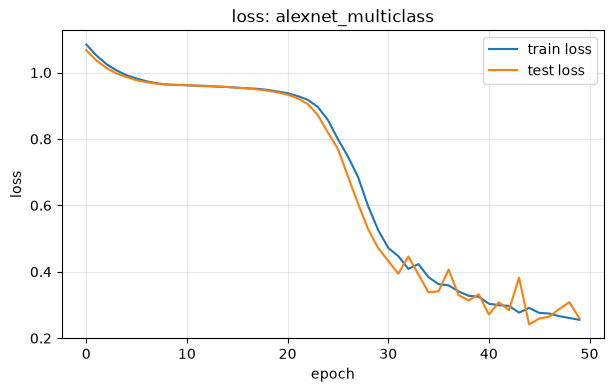

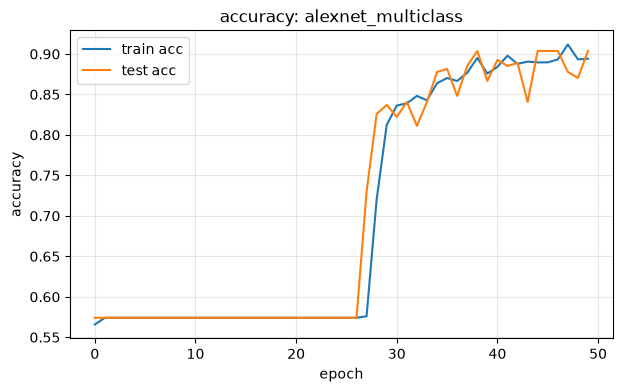

PosixPath('output/acc_alexnet_multiclass.png')

In [15]:
name = "alexnet_multiclass"

image_size = (227, 227)
batch_size = 32
num_classes = 3
lr = 1e-3
epochs = 50

train_loader, test_loader = get_cars_dataloader(
    image_size=image_size,
    batch_size=batch_size,
    split_mode="random",
)

alexnet = AlexNet(num_classes=num_classes)

optimizer = torch.optim.SGD(
    alexnet.parameters(),
    lr=lr,
    momentum=0.9,
    weight_decay=1e-4,
)

alexnet_history = train_model(
    alexnet,
    train_loader,
    test_loader,
    loss_fn=nn.CrossEntropyLoss(),
    optimizer=optimizer,
    num_epochs=epochs,
    task_type="multiclass",
    device=try_gpu(),
)

plot_loss_curve(alexnet_history, name)
plot_acc_curve(alexnet_history, name)

idx=117
path=../data/Cars/bus/bus051.jpg
true=bus, pred=bus
--------------------------------------------------
idx=37
path=../data/Cars/car/car675.jpg
true=car, pred=car
--------------------------------------------------
idx=155
path=../data/Cars/truck/truck105.jpg
true=truck, pred=truck
--------------------------------------------------


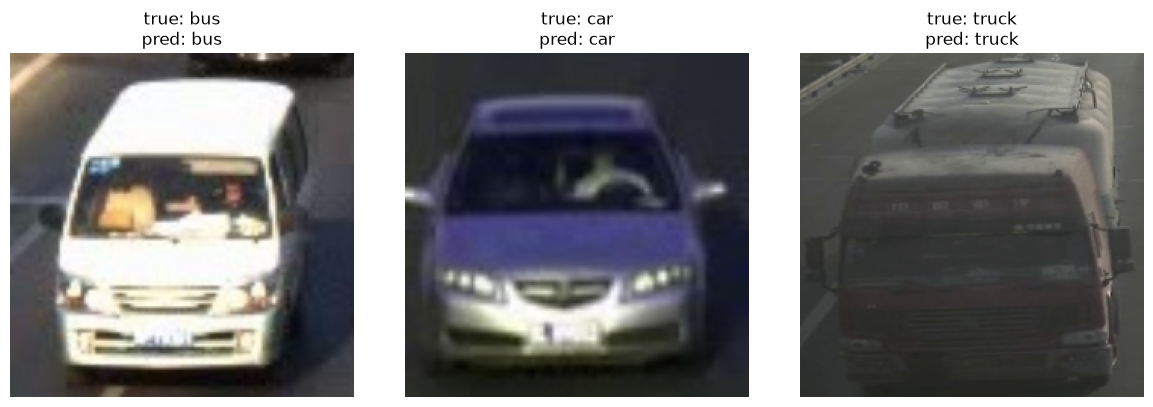

In [21]:
predict_random_one_per_class(
    model=alexnet,
    test_loader=test_loader,
    class_names=class_names,
    device=try_gpu(),
    seed=random.randint(0, 25565),
)

### 5.前馈神经网络

In [25]:
def get_torch_activation(name):
    if name == "relu":
        return nn.ReLU()

    if name == "tanh":
        return nn.Tanh()

    if name == "sigmoid":
        return nn.Sigmoid()

    if name == "leakyrelu":
        return nn.LeakyReLU(negative_slope=0.2)

    if name == "elu":
        return nn.ELU(alpha=0.2)

    raise ValueError(f"未知激活函数：{name}")


class TorchMLP(nn.Module):
    def __init__(self, layer_sizes, activation="relu", dropout=0.0):
        super().__init__()

        layers = []

        for i in range(len(layer_sizes) - 2):
            layers.append(nn.Linear(layer_sizes[i], layer_sizes[i + 1]))
            layers.append(get_torch_activation(activation))

            if dropout > 0:
                layers.append(nn.Dropout(p=dropout))

        layers.append(nn.Linear(layer_sizes[-2], layer_sizes[-1]))
        self.net = nn.Sequential(*layers)

    def forward(self, X):
        X = torch.flatten(X, 1)
        return self.net(X)

epoch 001 | train loss 1.0782 | test loss 1.0426 | train acc 0.4600 | test acc 0.5741
epoch 002 | train loss 1.0192 | test loss 0.9922 | train acc 0.5741 | test acc 0.5741
epoch 003 | train loss 0.9738 | test loss 0.9640 | train acc 0.5741 | test acc 0.5741
epoch 004 | train loss 0.9488 | test loss 0.9473 | train acc 0.5741 | test acc 0.5741
epoch 005 | train loss 0.9345 | test loss 0.9361 | train acc 0.5741 | test acc 0.5741
epoch 006 | train loss 0.9231 | test loss 0.9261 | train acc 0.5741 | test acc 0.5741
epoch 007 | train loss 0.9096 | test loss 0.9144 | train acc 0.5741 | test acc 0.5741
epoch 008 | train loss 0.8984 | test loss 0.9019 | train acc 0.5741 | test acc 0.5741
epoch 009 | train loss 0.8904 | test loss 0.8878 | train acc 0.5741 | test acc 0.5741
epoch 010 | train loss 0.8711 | test loss 0.8724 | train acc 0.5741 | test acc 0.5741
epoch 011 | train loss 0.8556 | test loss 0.8564 | train acc 0.5741 | test acc 0.5741
epoch 012 | train loss 0.8411 | test loss 0.8384 | tra

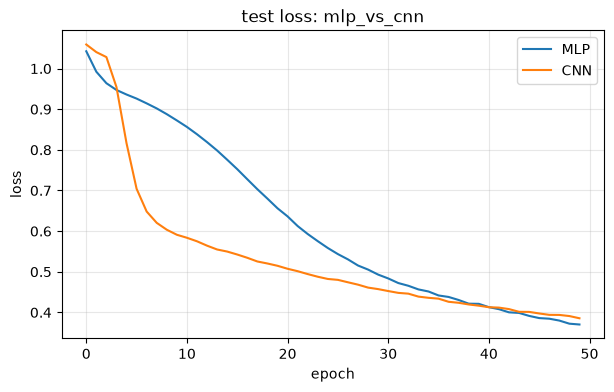

PosixPath('output/test_loss_mlp_vs_cnn.png')

In [28]:
image_size = (32, 32)
batch_size = 128
num_classes = 3
lr = 1e-3
epochs = 50
device = try_gpu()

train_loader, test_loader = get_cars_dataloader(
    image_size=image_size,
    batch_size=batch_size,
    split_mode="random",
)

input_dim = 3 * image_size[0] * image_size[1]

# 1. MLP
mlp = TorchMLP(
    layer_sizes=[input_dim, 512, 128, num_classes],
    activation="relu",
    dropout=0.2,
)

mlp_optimizer = torch.optim.SGD(
    mlp.parameters(),
    lr=lr,
    momentum=0.9,
    weight_decay=1e-4,
)

mlp_history = train_model(
    mlp,
    train_loader,
    test_loader,
    loss_fn=nn.CrossEntropyLoss(),
    optimizer=mlp_optimizer,
    num_epochs=epochs,
    task_type="multiclass",
    device=device,
)

# 2. CNN
conv = ConvModule(num_classes=num_classes)

conv_optimizer = torch.optim.SGD(
    conv.parameters(),
    lr=lr,
    momentum=0.9,
    weight_decay=1e-4,
)

conv_history = train_model(
    conv,
    train_loader,
    test_loader,
    loss_fn=nn.CrossEntropyLoss(),
    optimizer=conv_optimizer,
    num_epochs=epochs,
    task_type="multiclass",
    device=device,
)

plot_loss_curves(
    history_list=[mlp_history, conv_history],
    task_list=["MLP", "CNN"],
    fig_name="mlp_vs_cnn",
    loss_type="test",
)

从测试损失曲线可以看出，卷积神经网络在训练初期下降更快，说明其对图像局部空间结构的建模能力更强；多层感知机前期收敛较慢，但在后期逐渐逼近卷积网络，最终测试损失略低于卷积网络。总体而言，CNN 的收敛速度更快，而 MLP 在充分训练后也能取得较好的分类效果。

## 空洞卷积实验

In [15]:
class DilatedConvBlock(nn.Module):
    """
    单层空洞卷积模块（3*3）
    配置规则：kernel=3, stride=1, padding=dilation, dilation=dilation
    数学公式保证：输出高宽 = 输入高宽，只改变通道数
    Args:
        in_channels: 输入通道数
        out_channels: 输出通道数
        dilation: 空洞膨胀率 D
    Input shape:  [B, C_in, H, W]
    Output shape: [B, C_out, H, W]
    """

    def __init__(self, in_channels, out_channels, dilation):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(
                in_channels=in_channels,
                out_channels=out_channels,
                kernel_size=3,
                stride=1,
                padding=dilation,  # 关键：padding=D 保证尺寸不变
                dilation=dilation,
                bias=False,
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        # x: [B, C_in, H, W] -> [B, C_out, H, W]
        return self.block(x)


class DilatedDehazeNet(nn.Module):
    """
    基于HDC混合空洞卷积的去雾网络
    HDC膨胀率序列：[1, 2, 5] 满足 gcd(1,2,5)=1，消除网格采样空洞
    整体流程：浅层提取 -> HDC串行提取多尺度上下文 -> 通道拼接融合 -> 输出去雾图
    """

    def __init__(self, in_channels=3, out_channels=3, base_channels=32):
        super().__init__()
        self.base_channels = base_channels

        # 1. Stem 浅层初始特征提取，普通3*3卷积，尺寸保持不变
        self.stem = nn.Sequential(
            nn.Conv2d(
                in_channels=in_channels,
                out_channels=base_channels,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(base_channels),
            nn.ReLU(inplace=True),
        )

        # 2. HDC 三层串行空洞卷积块 dilation=[1,2,5]
        # block1: dilation=1 等价普通3*3卷积，捕捉局部细节
        self.block1 = DilatedConvBlock(base_channels, base_channels, dilation=1)
        # block2: dilation=2 中等感受野
        self.block2 = DilatedConvBlock(base_channels, base_channels, dilation=2)
        # block3: dilation=5 超大感受野，捕捉全局雾层分布
        self.block3 = DilatedConvBlock(base_channels, base_channels, dilation=5)

        # 3. 多尺度特征融合层：3个分支通道拼接后降维
        # 拼接后通道数 = base_channels * 3，卷积压缩回base_channels
        self.fuse = nn.Sequential(
            nn.Conv2d(
                in_channels=base_channels * 3,
                out_channels=base_channels,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(base_channels),
            nn.ReLU(inplace=True),
        )

        # 4. 输出Head，映射回RGB三通道图像
        self.head = nn.Conv2d(
            in_channels=base_channels,
            out_channels=out_channels,
            kernel_size=3,
            stride=1,
            padding=1,
        )

    def forward(self, x):
        """
        假设输入 x shape: [B, 3, H, W]
        逐行张量形状变化推演
        """
        # --------------------------
        # Step1: Stem 初始卷积提取
        # [B, 3, H, W] --> [B, 32, H, W]
        # --------------------------
        feat = self.stem(x)

        # --------------------------
        # Step2: HDC串行三层空洞卷积，每层H/W不变，通道保持32
        # --------------------------
        f1 = self.block1(feat)  # [B, 32, H, W]  dilation=1
        f2 = self.block2(f1)  # [B, 32, H, W]  dilation=2
        f3 = self.block3(f2)  # [B, 32, H, W]  dilation=5

        # --------------------------
        # Step3: 通道维度拼接 concat(dim=1)
        # 三个特征图在通道堆叠：32+32+32 = 96通道
        # [B, 32, H, W] cat 三次 --> [B, 96, H, W]
        # --------------------------
        fused = torch.cat([f1, f2, f3], dim=1)

        # --------------------------
        # Step4: 融合卷积降维，96通道压缩回32通道
        # [B, 96, H, W] --> [B, 32, H, W]
        # --------------------------
        fused = self.fuse(fused)

        # --------------------------
        # Step5: 预测头输出RGB图像
        # [B, 32, H, W] --> [B, 3, H, W]
        # clamp限制像素值在0~1之间，符合图像归一化范围
        # --------------------------
        out = self.head(fused)
        out = torch.clamp(out, 0.0, 1.0)

        return out

In [16]:
image_size = (224, 224)
batch_size = 8
lr = 1e-3
epochs = 50
device = try_gpu()

train_loader, test_loader = get_dehaze_dataloader(
    data_dir="../data/Dehaze",
    image_size=image_size,
    batch_size=batch_size,
    test_ratio=0.2,
    num_workers=0,
)

model = DilatedDehazeNet(
    in_channels=3,
    out_channels=3,
    base_channels=32,
).to(device)

loss_fn = L1SSIMLoss(alpha=0.8)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=lr,
    weight_decay=1e-4,
)

history = train_model(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    num_epochs=epochs,
    task_type="regression",
    device=device,
)

epoch 001 | train loss 0.1311 | test loss 0.0829 | MAE 0.074671 | RMSE 0.092795 | PSNR 20.6495 | SSIM 0.8840
epoch 002 | train loss 0.0833 | test loss 0.0668 | MAE 0.062079 | RMSE 0.079620 | PSNR 21.9796 | SSIM 0.9142
epoch 003 | train loss 0.0751 | test loss 0.0580 | MAE 0.055163 | RMSE 0.072956 | PSNR 22.7388 | SSIM 0.9307
epoch 004 | train loss 0.0737 | test loss 0.0676 | MAE 0.061765 | RMSE 0.081173 | PSNR 21.8118 | SSIM 0.9092
epoch 005 | train loss 0.0743 | test loss 0.0605 | MAE 0.058701 | RMSE 0.077606 | PSNR 22.2021 | SSIM 0.9322
epoch 006 | train loss 0.0750 | test loss 0.0621 | MAE 0.058507 | RMSE 0.076400 | PSNR 22.3381 | SSIM 0.9234
epoch 007 | train loss 0.0736 | test loss 0.0633 | MAE 0.060851 | RMSE 0.077426 | PSNR 22.2222 | SSIM 0.9268
epoch 008 | train loss 0.0711 | test loss 0.0694 | MAE 0.066728 | RMSE 0.082680 | PSNR 21.6519 | SSIM 0.9202
epoch 009 | train loss 0.0695 | test loss 0.0672 | MAE 0.066419 | RMSE 0.084938 | PSNR 21.4180 | SSIM 0.9297
epoch 010 | train l

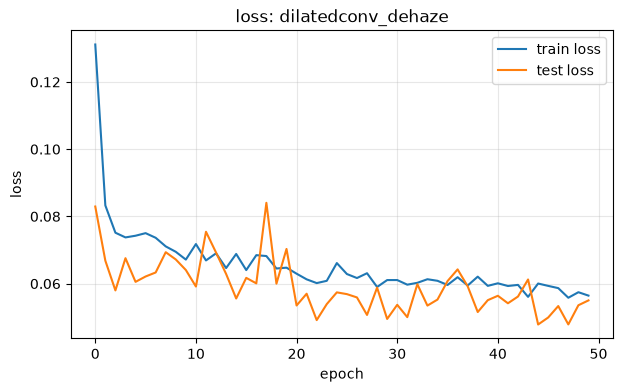

PosixPath('output/loss_dilatedconv_dehaze.png')

In [17]:
name = "dilatedconv_dehaze"
plot_loss_curve(history, name)

idx=2
hazy_path=../data/Dehaze/haze/419.jpg
clear_path=../data/Dehaze/clear/419.jpg
--------------------------------------------------
idx=67
hazy_path=../data/Dehaze/haze/484.jpg
clear_path=../data/Dehaze/clear/484.jpg
--------------------------------------------------
idx=86
hazy_path=../data/Dehaze/haze/503.jpg
clear_path=../data/Dehaze/clear/503.jpg
--------------------------------------------------


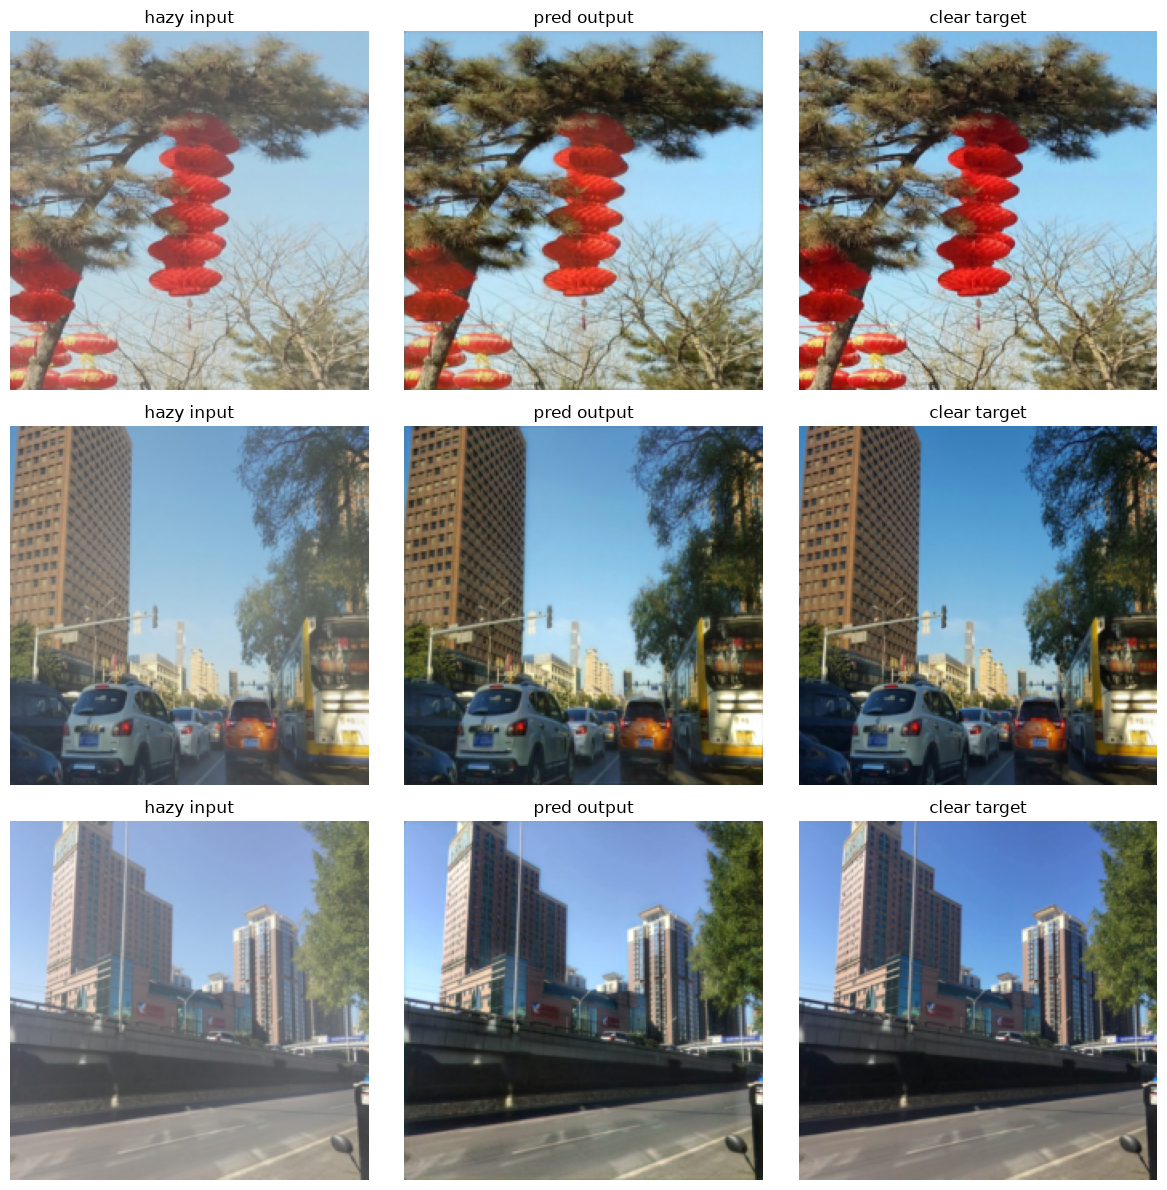

In [23]:
show_dehaze_random_samples(
    model=model,
    test_loader=test_loader,
    num_samples=3,
    device=device,
    seed=random.randint(0, 25565),
)

## 残差网络实验

### 1.实现给定残差网络

In [18]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False,
        )
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(
            out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels, out_channels, kernel_size=1, stride=stride, bias=False
                ),
                nn.BatchNorm2d(out_channels),
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        identity = self.shortcut(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out = out + identity
        out = self.relu(out)
        return out


class UpBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            ResidualBlock(out_channels, out_channels),
        )

    def forward(self, x, target_size):
        x = F.interpolate(x, size=target_size, mode="bilinear", align_corners=False)
        x = self.block(x)
        return x


class ResNetRegressor(nn.Module):
    def __init__(self, in_channels=3, out_channels=3):
        super().__init__()

        # stem: 32x32 -> 32x32
        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        )

        # 对应图里的 64 通道残差堆叠
        self.stage1 = nn.Sequential(
            ResidualBlock(64, 64),
            ResidualBlock(64, 64),
            ResidualBlock(64, 64),
        )

        # 32x32 -> 16x16
        self.stage2 = nn.Sequential(
            ResidualBlock(64, 128, stride=2),
            ResidualBlock(128, 128),
        )

        # 16x16 -> 8x8
        self.stage3 = nn.Sequential(
            ResidualBlock(128, 256, stride=2),
            ResidualBlock(256, 256),
        )

        # 8x8 -> 4x4
        self.stage4 = nn.Sequential(
            ResidualBlock(256, 512, stride=2),
            ResidualBlock(512, 512),
        )

        # 回归任务不再做 avg pool + fc，而是逐步上采样恢复分辨率
        self.up3 = UpBlock(512, 256)  # 4x4 -> 8x8
        self.up2 = UpBlock(256, 128)  # 8x8 -> 16x16
        self.up1 = UpBlock(128, 64)  # 16x16 -> 32x32

        self.head = nn.Sequential(
            nn.Conv2d(64, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, out_channels, kernel_size=3, padding=1),
        )

    def forward(self, x):
        x0 = self.stem(x)  # [B, 64, H, W]
        x1 = self.stage1(x0)  # [B, 64, H, W]
        x2 = self.stage2(x1)  # [B, 128, H/2, W/2]
        x3 = self.stage3(x2)  # [B, 256, H/4, W/4]
        x4 = self.stage4(x3)  # [B, 512, H/8, W/8]

        y = self.up3(x4, x3.shape[-2:])  # [B, 256, H/4, W/4]
        y = self.up2(y, x2.shape[-2:])  # [B, 128, H/2, W/2]
        y = self.up1(y, x1.shape[-2:])  # [B, 64, H, W]

        y = self.head(y)
        y = torch.sigmoid(y)  # 输出限制到 [0, 1]
        return y

In [26]:
x = torch.randn(2, 3, 224, 224)
model = ResNetRegressor(in_channels=3, out_channels=3)
y = model(x)

print(x.shape)  # torch.Size([2, 3, 224, 224])
print(y.shape)  # torch.Size([2, 3, 224, 224])

torch.Size([2, 3, 224, 224])
torch.Size([2, 3, 224, 224])


In [27]:
image_size = (256, 256)
batch_size = 8
lr = 1e-3
epochs = 50
device = try_gpu()

train_loader, test_loader = get_dehaze_dataloader(
    data_dir="../data/Dehaze",
    image_size=image_size,
    batch_size=batch_size,
    test_ratio=0.2,
    num_workers=0,
)

model = ResNetRegressor(in_channels=3, out_channels=3).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=lr,
    weight_decay=1e-4,
)

loss_fn = L1SSIMLoss(alpha=0.8)

history = train_model(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    num_epochs=epochs,
    task_type="regression",
    device=device,
)

epoch 001 | train loss 0.2069 | test loss 0.1734 | MAE 0.102325 | RMSE 0.132873 | PSNR 17.5313 | SSIM 0.5421
epoch 002 | train loss 0.1663 | test loss 0.1625 | MAE 0.098089 | RMSE 0.122373 | PSNR 18.2463 | SSIM 0.5801
epoch 003 | train loss 0.1566 | test loss 0.1460 | MAE 0.086494 | RMSE 0.114871 | PSNR 18.7958 | SSIM 0.6158
epoch 004 | train loss 0.1509 | test loss 0.1603 | MAE 0.102220 | RMSE 0.135141 | PSNR 17.3843 | SSIM 0.6075
epoch 005 | train loss 0.1473 | test loss 0.1392 | MAE 0.084688 | RMSE 0.114135 | PSNR 18.8516 | SSIM 0.6425
epoch 006 | train loss 0.1414 | test loss 0.1455 | MAE 0.089688 | RMSE 0.116641 | PSNR 18.6630 | SSIM 0.6312
epoch 007 | train loss 0.1382 | test loss 0.1346 | MAE 0.081809 | RMSE 0.110584 | PSNR 19.1261 | SSIM 0.6543
epoch 008 | train loss 0.1354 | test loss 0.1296 | MAE 0.078220 | RMSE 0.103200 | PSNR 19.7264 | SSIM 0.6648
epoch 009 | train loss 0.1315 | test loss 0.1294 | MAE 0.077969 | RMSE 0.104287 | PSNR 19.6354 | SSIM 0.6649
epoch 010 | train l

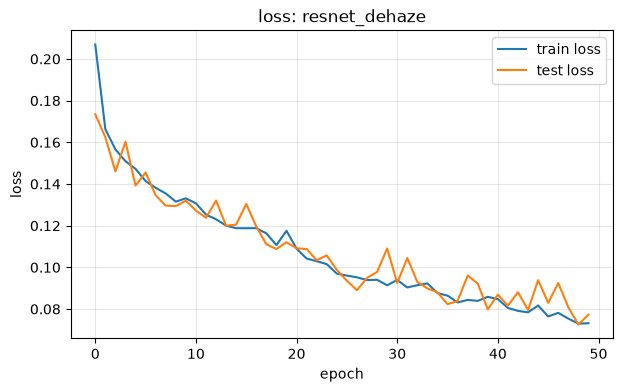

PosixPath('output/loss_resnet_dehaze.png')

In [28]:
name = "resnet_dehaze"
plot_loss_curve(history, name)

idx=19
hazy_path=../data/Dehaze/haze/436.jpg
clear_path=../data/Dehaze/clear/436.jpg
--------------------------------------------------
idx=49
hazy_path=../data/Dehaze/haze/466.jpg
clear_path=../data/Dehaze/clear/466.jpg
--------------------------------------------------
idx=64
hazy_path=../data/Dehaze/haze/481.jpg
clear_path=../data/Dehaze/clear/481.jpg
--------------------------------------------------


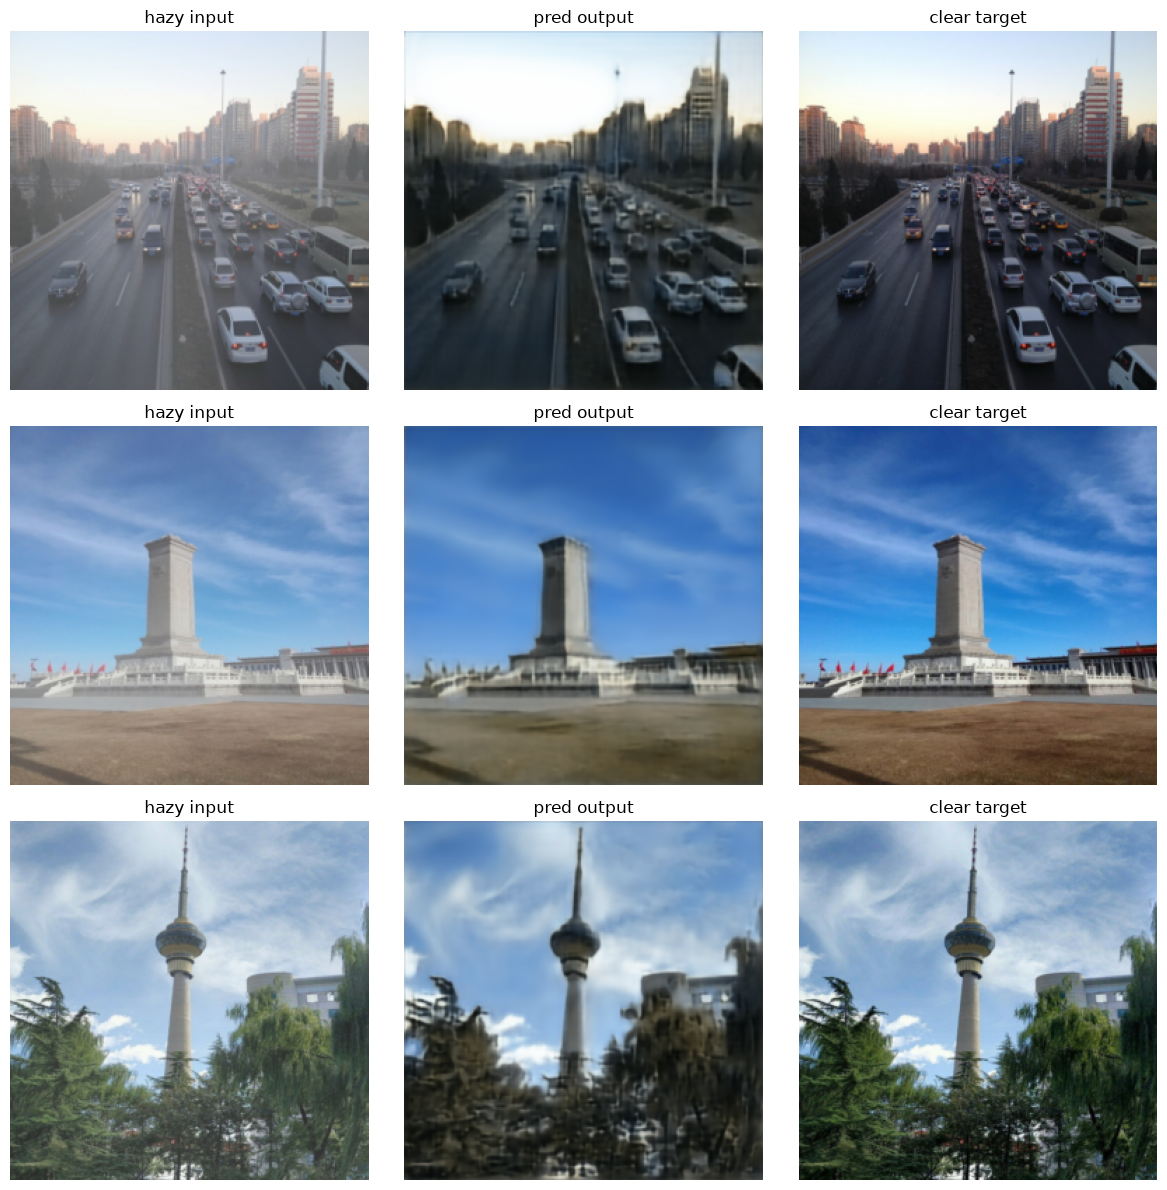

In [29]:
show_dehaze_random_samples(
    model=model,
    test_loader=test_loader,
    num_samples=3,
    device=device,
    seed=random.randint(0, 25565),
)

### 2.加入空洞卷积

In [19]:
class DilatedResidualBlock(nn.Module):
    def __init__(self, channels, dilation):
        super().__init__()

        self.conv1 = nn.Conv2d(
            channels,
            channels,
            kernel_size=3,
            stride=1,
            padding=dilation,
            dilation=dilation,
            bias=False,
        )
        self.bn1 = nn.BatchNorm2d(channels)

        self.conv2 = nn.Conv2d(
            channels,
            channels,
            kernel_size=3,
            stride=1,
            padding=dilation,
            dilation=dilation,
            bias=False,
        )
        self.bn2 = nn.BatchNorm2d(channels)

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out = out + identity
        out = self.relu(out)
        return out


class UpBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(
                in_channels + skip_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            ResidualBlock(out_channels, out_channels),
        )

    def forward(self, x, skip):
        x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)
        x = torch.cat([x, skip], dim=1)
        x = self.block(x)
        return x


class ResNetDilatedRegressor(nn.Module):
    def __init__(self, in_channels=3, out_channels=3, base_channels=32):
        super().__init__()

        c1 = base_channels
        c2 = base_channels * 2
        c3 = base_channels * 4

        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, c1, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(c1),
            nn.ReLU(inplace=True),
        )

        self.stage1 = nn.Sequential(
            ResidualBlock(c1, c1),
            ResidualBlock(c1, c1),
        )

        self.stage2 = nn.Sequential(
            ResidualBlock(c1, c2, stride=2),
            ResidualBlock(c2, c2),
        )

        self.stage3 = nn.Sequential(
            ResidualBlock(c2, c3, stride=2),
            ResidualBlock(c3, c3),
        )

        # 不再继续下采样，在 bottleneck 用空洞卷积扩大感受野
        self.dilated = nn.Sequential(
            DilatedResidualBlock(c3, dilation=1),
            DilatedResidualBlock(c3, dilation=2),
            DilatedResidualBlock(c3, dilation=5),
        )

        self.up2 = UpBlock(c3, c2, c2)
        self.up1 = UpBlock(c2, c1, c1)

        self.head = nn.Sequential(
            nn.Conv2d(c1, c1, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(c1, out_channels, kernel_size=3, padding=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        x0 = self.stem(x)  # [B, c1, H, W]
        x1 = self.stage1(x0)  # [B, c1, H, W]
        x2 = self.stage2(x1)  # [B, c2, H/2, W/2]
        x3 = self.stage3(x2)  # [B, c3, H/4, W/4]

        x4 = self.dilated(x3)  # [B, c3, H/4, W/4]

        y2 = self.up2(x4, x2)  # [B, c2, H/2, W/2]
        y1 = self.up1(y2, x1)  # [B, c1, H, W]

        out = self.head(y1)  # [B, 3, H, W]
        return out

In [20]:
x = torch.randn(2, 3, 256, 256)
model = ResNetDilatedRegressor(in_channels=3, out_channels=3, base_channels=32)
y = model(x)

print(x.shape)  # torch.Size([2, 3, 256, 256])
print(y.shape)  # torch.Size([2, 3, 256, 256])

torch.Size([2, 3, 256, 256])
torch.Size([2, 3, 256, 256])


In [21]:
image_size = (256, 256)
batch_size = 8
lr = 1e-3
epochs = 50
device = try_gpu()

train_loader, test_loader = get_dehaze_dataloader(
    data_dir="../data/Dehaze",
    image_size=image_size,
    batch_size=batch_size,
    test_ratio=0.2,
    num_workers=0,
)

model = ResNetDilatedRegressor(
    in_channels=3,
    out_channels=3,
    base_channels=32,
).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=lr,
    weight_decay=1e-4,
)

loss_fn = L1SSIMLoss(alpha=0.8)

history = train_model(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    num_epochs=epochs,
    task_type="regression",
    device=device,
)

epoch 001 | train loss 0.1096 | test loss 0.0692 | MAE 0.059265 | RMSE 0.077891 | PSNR 22.1702 | SSIM 0.8909
epoch 002 | train loss 0.0697 | test loss 0.0674 | MAE 0.062393 | RMSE 0.080147 | PSNR 21.9223 | SSIM 0.9126
epoch 003 | train loss 0.0670 | test loss 0.0659 | MAE 0.061624 | RMSE 0.081275 | PSNR 21.8008 | SSIM 0.9168
epoch 004 | train loss 0.0649 | test loss 0.0574 | MAE 0.053712 | RMSE 0.069726 | PSNR 23.1322 | SSIM 0.9278
epoch 005 | train loss 0.0653 | test loss 0.0567 | MAE 0.053254 | RMSE 0.069995 | PSNR 23.0987 | SSIM 0.9294
epoch 006 | train loss 0.0596 | test loss 0.0626 | MAE 0.057253 | RMSE 0.075197 | PSNR 22.4760 | SSIM 0.9161
epoch 007 | train loss 0.0612 | test loss 0.0541 | MAE 0.052612 | RMSE 0.066793 | PSNR 23.5054 | SSIM 0.9401
epoch 008 | train loss 0.0565 | test loss 0.0586 | MAE 0.055838 | RMSE 0.071078 | PSNR 22.9653 | SSIM 0.9304
epoch 009 | train loss 0.0557 | test loss 0.0583 | MAE 0.055563 | RMSE 0.073915 | PSNR 22.6254 | SSIM 0.9307
epoch 010 | train l

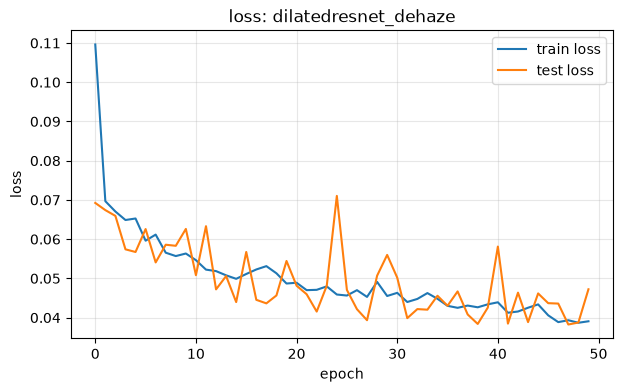

PosixPath('output/loss_dilatedresnet_dehaze.png')

In [22]:
name = "dilatedresnet_dehaze"
plot_loss_curve(history, name)

idx=22
hazy_path=../data/Dehaze/haze/439.jpg
clear_path=../data/Dehaze/clear/439.jpg
--------------------------------------------------
idx=69
hazy_path=../data/Dehaze/haze/486.jpg
clear_path=../data/Dehaze/clear/486.jpg
--------------------------------------------------
idx=36
hazy_path=../data/Dehaze/haze/453.jpg
clear_path=../data/Dehaze/clear/453.jpg
--------------------------------------------------


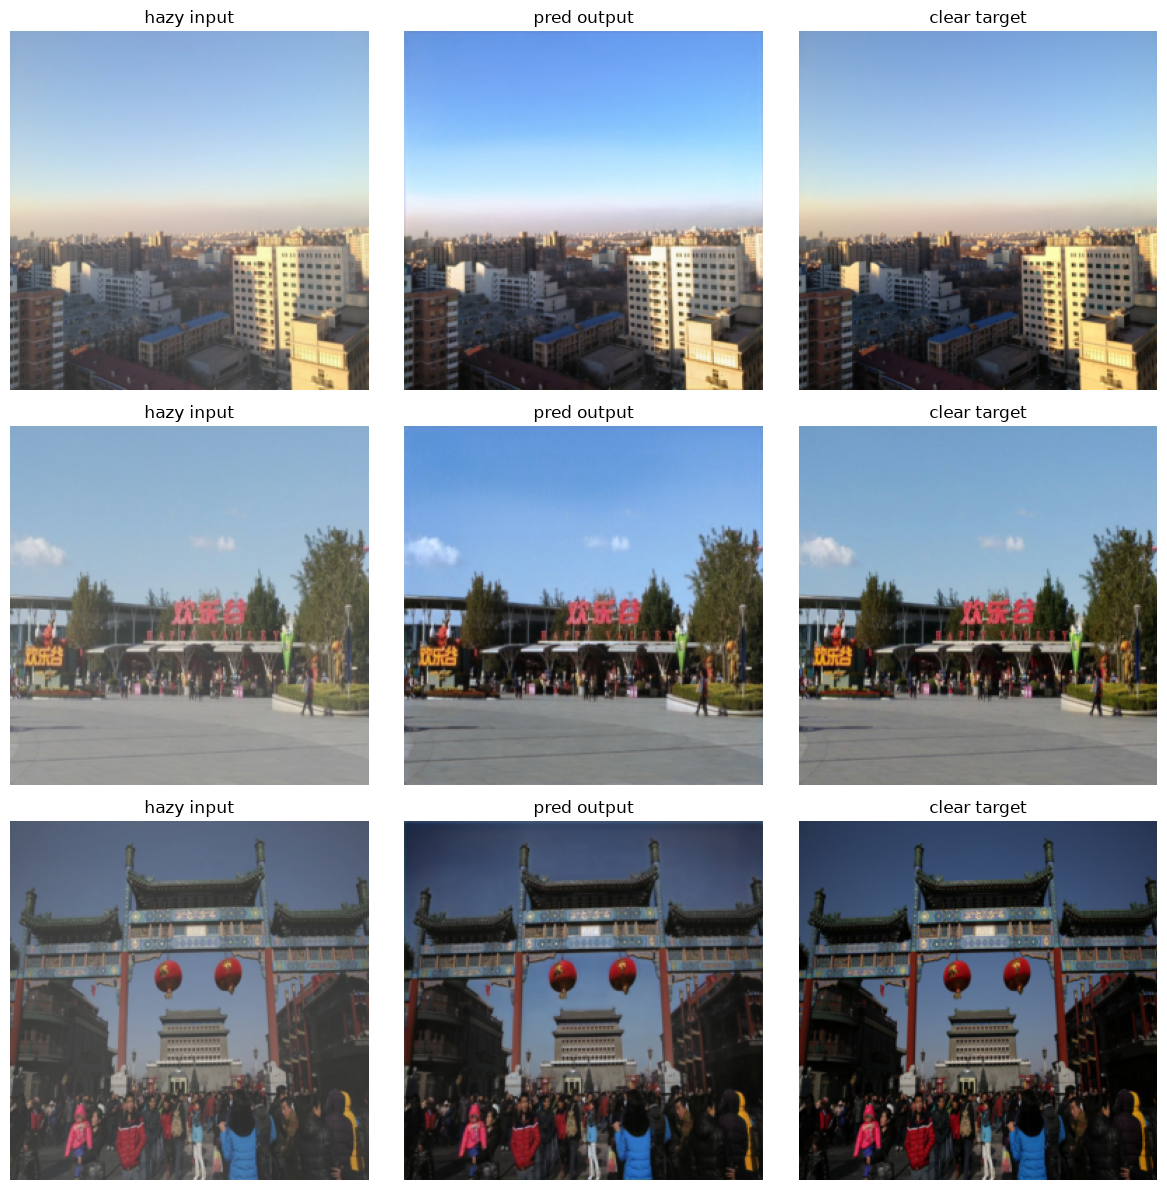

In [23]:
show_dehaze_random_samples(
    model=model,
    test_loader=test_loader,
    num_samples=3,
    device=device,
    seed=random.randint(0, 25565),
)

实验结果表明，在残差网络的瓶颈部分引入空洞卷积后，模型能够在不进一步降低特征图分辨率的情况下有效扩大感受野，从而提升去雾任务的重建质量。相比普通残差网络，改进后的模型取得了更低的测试损失以及更高的 PSNR 和 SSIM，说明空洞卷积与残差结构的结合是有效的。